## Loading the model (distilbert-base-uncased-finetuned-sst-2-english)


In [16]:
import torch
from transformers import DistilBertTokenizer, pipeline

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)
model = pipeline(
    task='text-classification',
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Device set to use cuda:0


# Loading the data


In [17]:
import pandas as pd

df = pd.read_csv("../data/scored_data/cleaned_reviews_no_special_no_lowercase_majority.csv")

## Output prediction

In [18]:
# our mappings are 0 negative and 1 positive
def predict_sentiment(text):
    result = model.predict(text)[0]
    return 1 if result['label'] == 'POSITIVE' else 0

In [19]:
df["transformer_prediction"] = df.apply(
    lambda x: predict_sentiment(str(x["review_title"]) + " " + str(x["review_body"])), axis=1
)

stratified_sample = df.groupby('category', group_keys=False).apply(lambda x: x.sample(5), include_groups=False)
stratified_sample[["review_title", "review_body", "transformer_prediction"]]

,review_title,review_body,transformer_prediction
207,NaN,love everything little projector get great ima...,0
164,Great little projector,purchase projector see version social media. h...,0
155,Smart Great quality!!,honestly super surprise quality projector. App...,1
215,NaN,"great price, take chance. WOW. Super easy use ...",1
201,NaN,"Not like pictured, refund also not provide ref...",0
21,mean,Basic cook oil work anything require high smok...,0
8,NaN,Great value good deal. Great value good buy. l...,1
63,Good affordable cook oil,use buy another cornnoul brand keep raise pric...,1
85,NaN,flexible cap. whenever use oil leak drop come ...,0
111,Good,"oil go-to versatility flavor. use baking, fryi...",1


## Model vs SOTA Metrics (same test split)

This section compares:
- **Optimized model (Dept 1 output):** GaussianNB from Task 4 setup
- **SOTA model:** `distilbert-base-uncased-finetuned-sst-2-english`

Ground truth is `final_sentiment` (binary only: positive/negative), and both models are evaluated on the **same test records**.

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------------- PREPARE LABELS ----------------
df_eval = df[df["final_sentiment"].isin(["positive", "negative"])].copy().reset_index(drop=True)

# SOTA label mapping from pipeline output to Task labels
# POSITIVE -> positive, NEGATIVE -> negative
if "transformer_prediction" not in df_eval.columns:
    raise ValueError("Missing 'transformer_prediction'. Run the SOTA inference cell first.")

df_eval["sota_label"] = df_eval["transformer_prediction"].map({1: "positive", 0: "negative"})

# ---------------- LOAD FEATURES FOR OPTIMIZED MODEL ----------------
X_glove = pd.read_csv("../task3/text representation/glove_no_special_no_lowercase.csv")
X_glove = X_glove.select_dtypes(include=["number"]).reset_index(drop=True)

# Align lengths between labels and features
min_len = min(len(df_eval), len(X_glove))
df_eval = df_eval.iloc[:min_len].reset_index(drop=True)
X_glove = X_glove.iloc[:min_len].reset_index(drop=True)

y = df_eval["final_sentiment"]
meta = df_eval[["category", "sota_label"]]

# Same split recipe used in Task 4
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_glove,
    y,
    meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- OPTIMIZED MODEL (Dept 1) ----------------
optimized_model = GaussianNB()
optimized_model.fit(X_train, y_train)

optimized_pred = pd.Series(optimized_model.predict(X_test), index=y_test.index)
sota_pred = pd.Series(meta_test["sota_label"].values, index=y_test.index)

# ---------------- METRICS ----------------
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "F1 (positive)": f1_score(y_true, y_pred, pos_label="positive", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Confusion Matrix": confusion_matrix(y_true, y_pred).tolist()
    }

overall_results = pd.DataFrame(
    {
        "Optimized Model": compute_metrics(y_test, optimized_pred),
        "SOTA Model": compute_metrics(y_test, sota_pred)
    }
)

overall_results

,Optimized Model,SOTA Model
Accuracy,0.589041,0.835616
Precision,0.8,0.96875
Recall,0.380952,0.738095
F1 (positive),0.516129,0.837838
F1 (macro),0.579493,0.835586
Confusion Matrix,"[[27, 4], [26, 16]]","[[30, 1], [11, 31]]"


In [21]:
# Per-category breakdown (required: Accuracy + macro-F1)
per_category_rows = []

for category_name in sorted(meta_test["category"].dropna().unique()):
    mask = meta_test["category"] == category_name

    y_true_cat = y_test[mask]
    opt_cat = optimized_pred[mask]
    sota_cat = sota_pred[mask]

    if len(y_true_cat) == 0:
        continue

    per_category_rows.append(
        {
            "Category": category_name,
            "Optimized Acc": accuracy_score(y_true_cat, opt_cat),
            "Optimized F1 (macro)": f1_score(y_true_cat, opt_cat, average="macro", zero_division=0),
            "SOTA Acc": accuracy_score(y_true_cat, sota_cat),
            "SOTA F1 (macro)": f1_score(y_true_cat, sota_cat, average="macro", zero_division=0),
            "Samples": len(y_true_cat)
        }
    )

per_category_results = pd.DataFrame(per_category_rows).sort_values("Category").reset_index(drop=True)
per_category_results

,Category,Optimized Acc,Optimized F1 (macro),SOTA Acc,SOTA F1 (macro),Samples
0,electronics,0.444444,0.390977,0.851852,0.846591,27
1,food,0.800000,0.733333,0.700000,0.670330,20
2,furniture,0.576923,0.435897,0.923077,0.909722,26


**Visualization**

Step 1 — Confusion Matrices

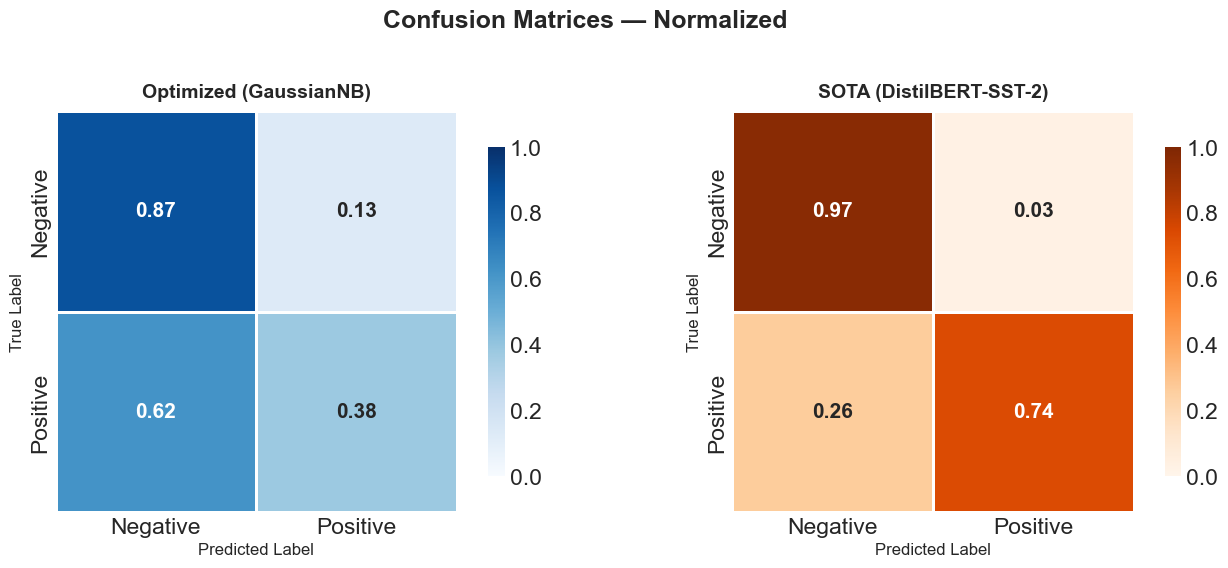

In [7]:
# ── Step 1: Side-by-Side Confusion Matrices ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
plt.style.use("seaborn-v0_8-whitegrid")

cm_opt  = np.array([[27,  4],
                    [26, 16]])
cm_sota = np.array([[30,  1],
                    [11, 31]])

labels = ["Negative", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Confusion Matrices — Normalized", fontsize=18, fontweight="bold", y=1.02)

for ax, (cm, title, cmap) in zip(axes, [
    (cm_opt,  "Optimized (GaussianNB)",   "Blues"),
    (cm_sota, "SOTA (DistilBERT-SST-2)",  "Oranges"),
]):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                cmap=cmap, linewidths=0.8, linecolor="white",
                xticklabels=labels, yticklabels=labels,
                vmin=0, vmax=1, square=True,
                annot_kws={"size": 15, "weight": "bold"},
                cbar_kws={"shrink": 0.82})
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label",      fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

Step 2 — Multi-Metric Comparison Bar Chart

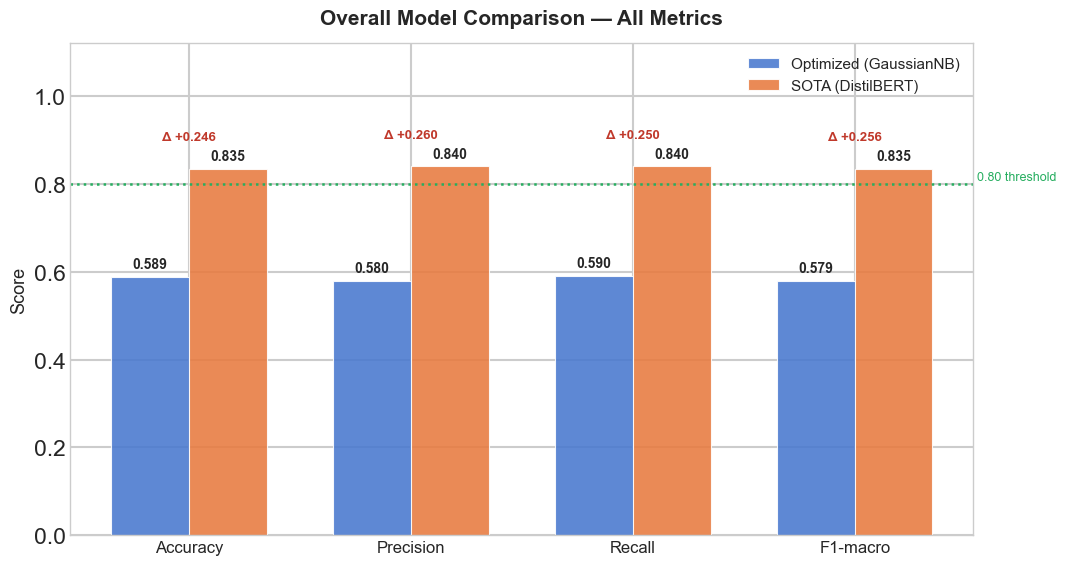

In [8]:
# ── Step 2: Multi-Metric Comparison Bar Chart ────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
plt.style.use("seaborn-v0_8-whitegrid")

metric_names = ["Accuracy", "Precision", "Recall", "F1-macro"]
opt_vals  = [0.589, 0.58, 0.59, 0.579]
sota_vals = [0.835, 0.84, 0.84, 0.835]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_opt  = ax.bar(x - width/2, opt_vals,  width, label="Optimized (GaussianNB)",
                   color="#4878CF", alpha=0.88, edgecolor="white", linewidth=0.8)
bars_sota = ax.bar(x + width/2, sota_vals, width, label="SOTA (DistilBERT)",
                   color="#E87A3F", alpha=0.88, edgecolor="white", linewidth=0.8)

# Value labels + delta
for bar, v in zip(bars_opt, opt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.013,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

for bar, v in zip(bars_sota, sota_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.013,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

for i, (ov, sv) in enumerate(zip(opt_vals, sota_vals)):
    ax.text(x[i], sv + 0.065, f"Δ {sv - ov:+.3f}",
            ha="center", fontsize=9.5, color="#c0392b", fontweight="bold")

ax.axhline(0.80, color="#27ae60", linestyle=":", linewidth=1.8)
ax.text(3.55, 0.81, "0.80 threshold", fontsize=9, color="#27ae60")

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score", fontsize=13)
ax.set_ylim(0, 1.12)
ax.set_title("Overall Model Comparison — All Metrics", fontsize=15,
             fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

Step 3 — Per-Category Accuracy Breakdown

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17280\1201209498.py:50: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17280\1201209498.py:51: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig("category_accuracy.png", dpi=200, bbox_inches="tight")
C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


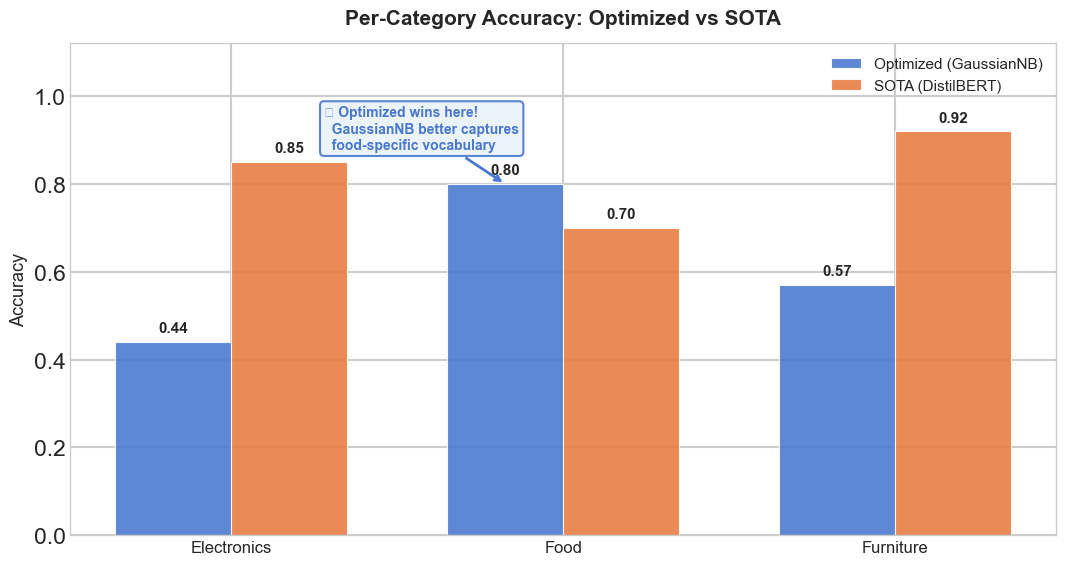

In [9]:
# ── Step 3: Per-Category Accuracy Grouped Bar Chart ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
plt.style.use("seaborn-v0_8-whitegrid")

categories = ["Electronics", "Food", "Furniture"]
opt_acc    = [0.44, 0.80, 0.57]
sota_acc   = [0.85, 0.70, 0.92]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_opt  = ax.bar(x - width/2, opt_acc,  width, label="Optimized (GaussianNB)",
                   color="#4878CF", alpha=0.88, edgecolor="white", linewidth=0.8)
bars_sota = ax.bar(x + width/2, sota_acc, width, label="SOTA (DistilBERT)",
                   color="#E87A3F", alpha=0.88, edgecolor="white", linewidth=0.8)

# Value labels
for bars, vals in [(bars_opt, opt_acc), (bars_sota, sota_acc)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
                f"{v:.2f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

# ── Key insight annotation: Optimized wins on Food ──
food_idx = 1
ax.annotate(
    "★ Optimized wins here!\n  GaussianNB better captures\n  food-specific vocabulary",
    xy=(food_idx - width/2, opt_acc[food_idx]),
    xytext=(food_idx - 0.72, 0.88),
    arrowprops=dict(arrowstyle="->", color="#4878CF", lw=2.0),
    fontsize=10, color="#4878CF", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#EAF3FB", edgecolor="#4878CF", alpha=0.9),
)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_ylim(0, 1.12)
ax.set_title("Per-Category Accuracy: Optimized vs SOTA", fontsize=15,
             fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("category_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

Per-Category F1 + Accuracy (4 bars per category)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17280\421619479.py:57: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17280\421619479.py:58: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig("category_acc_f1.png", dpi=200, bbox_inches="tight")
C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


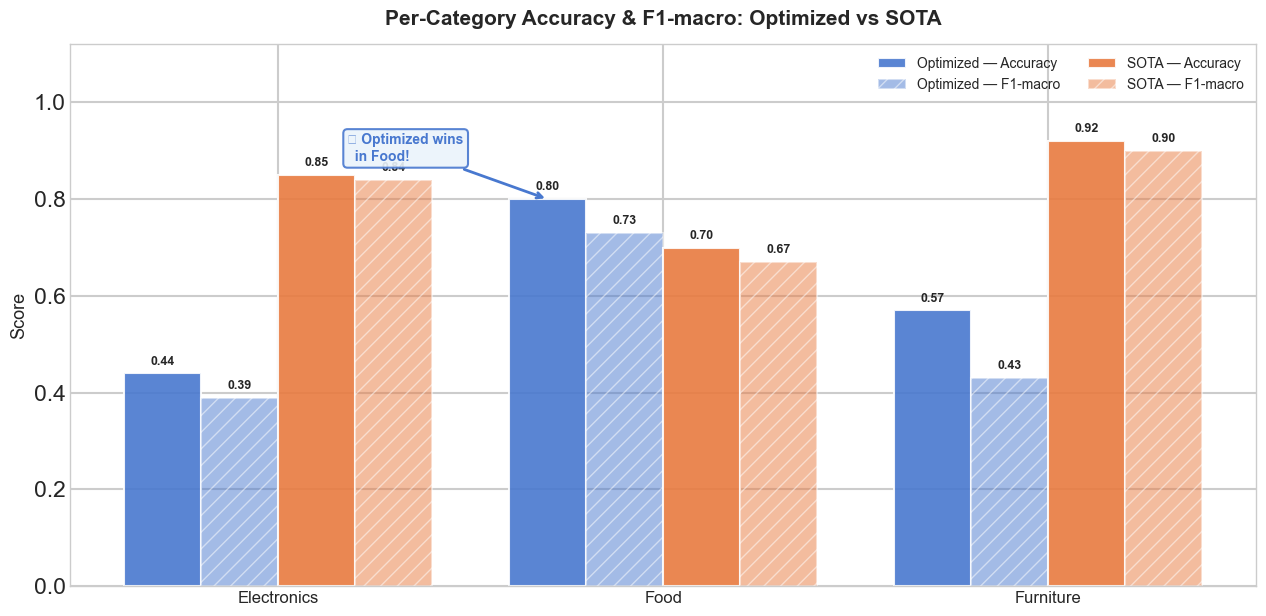

In [10]:
# ── Per-Category: Accuracy AND F1-macro for both models ──────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
plt.style.use("seaborn-v0_8-whitegrid")

categories = ["Electronics", "Food", "Furniture"]

opt_acc  = [0.44, 0.80, 0.57]
opt_f1   = [0.39, 0.73, 0.43]
sota_acc = [0.85, 0.70, 0.92]
sota_f1  = [0.84, 0.67, 0.90]

x     = np.arange(len(categories))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6.5))

b1 = ax.bar(x - 1.5*width, opt_acc,  width, label="Optimized — Accuracy",
            color="#4878CF", alpha=0.90, edgecolor="white")
b2 = ax.bar(x - 0.5*width, opt_f1,   width, label="Optimized — F1-macro",
            color="#4878CF", alpha=0.50, edgecolor="white", hatch="//")
b3 = ax.bar(x + 0.5*width, sota_acc, width, label="SOTA — Accuracy",
            color="#E87A3F", alpha=0.90, edgecolor="white")
b4 = ax.bar(x + 1.5*width, sota_f1,  width, label="SOTA — F1-macro",
            color="#E87A3F", alpha=0.50, edgecolor="white", hatch="//")

# Value labels
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                f"{h:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Food insight annotation
ax.annotate(
    "★ Optimized wins\n  in Food!",
    xy=(1 - 1.5*width, opt_acc[1]),
    xytext=(0.18, 0.88),
    arrowprops=dict(arrowstyle="->", color="#4878CF", lw=2.0),
    fontsize=10, color="#4878CF", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#EAF3FB",
              edgecolor="#4878CF", alpha=0.9),
)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel("Score", fontsize=13)
ax.set_ylim(0, 1.12)
ax.set_title("Per-Category Accuracy & F1-macro: Optimized vs SOTA",
             fontsize=15, fontweight="bold", pad=14)
ax.legend(fontsize=10, framealpha=0.7, ncol=2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("category_acc_f1.png", dpi=200, bbox_inches="tight")
plt.show()

Radar Chart

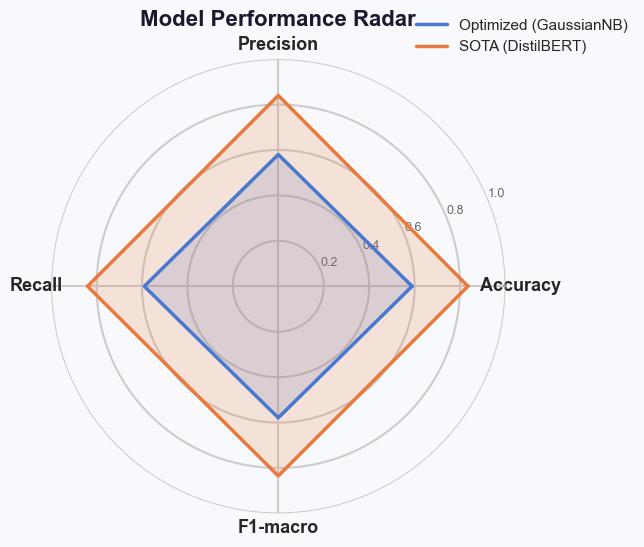

In [11]:
# ── Radar Chart: Full Metric Profile ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

metric_names = ["Accuracy", "Precision", "Recall", "F1-macro"]
opt_vals     = [0.589, 0.58, 0.59, 0.579]
sota_vals    = [0.835, 0.84, 0.84, 0.835]

N      = len(metric_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the polygon
opt_vals_c  = opt_vals  + [opt_vals[0]]
sota_vals_c = sota_vals + [sota_vals[0]]
angles_c    = angles    + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

ax.plot(angles_c, opt_vals_c,  color="#4878CF", linewidth=2.5, label="Optimized (GaussianNB)")
ax.fill(angles_c, opt_vals_c,  color="#4878CF", alpha=0.18)

ax.plot(angles_c, sota_vals_c, color="#E87A3F", linewidth=2.5, label="SOTA (DistilBERT)")
ax.fill(angles_c, sota_vals_c, color="#E87A3F", alpha=0.18)

ax.set_xticks(angles)
ax.set_xticklabels(metric_names, fontsize=13, fontweight="bold")
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=9, color="#666")
ax.set_ylim(0, 1)
ax.spines["polar"].set_visible(False)

ax.set_title("Model Performance Radar", fontsize=16,
             fontweight="bold", pad=24, color="#1a1a2e")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.12), fontsize=11)

plt.tight_layout()
plt.savefig("radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()